# DiReCT dataset audit

This notebook reports aggregate corpus structure, guideline graph inventory, annotation volume, and released-label quality flags.

In [1]:
from collections import Counter
from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "clinical_cds").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / "output/.matplotlib"))

'/Users/oluwatosinoso/Library/CloudStorage/OneDrive-hull.ac.uk/argumentation_schemes/output/.matplotlib'

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from clinical_cds.direct import load_direct_dataset, select_direct_partition

In [3]:
DIRECT_ROOT = REPO_ROOT / "data/mimic_iv_ext_direct/unpacked"
OUTPUT_DIR = REPO_ROOT / "output/notebook_artifacts/direct_audit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dataset = load_direct_dataset(DIRECT_ROOT)

## Corpus summary

In [4]:
audit = dataset.audit.to_dict()
audit["annotation_node_count"] = sum(len(case.annotation_nodes) for case in dataset.cases)
audit["gold_observation_count"] = sum(len(case.gold_observations) for case in dataset.cases)
audit["development_case_count"] = len(select_direct_partition(dataset.cases, "development"))
audit["test_case_count"] = len(select_direct_partition(dataset.cases, "test"))

audit_table = pd.DataFrame(
    [(name, value) for name, value in audit.items() if not isinstance(value, (list, dict))],
    columns=["measure", "value"],
)
audit_table.to_csv(OUTPUT_DIR / "direct_audit_summary.csv", index=False)
audit_table

,measure,value
0,case_count,511
1,graph_count,24
2,disease_category_count,25
3,diagnosis_count,62
4,empty_section_count,12
5,folder_conclusion_mismatch_count,115
6,annotation_node_count,11789
7,gold_observation_count,5109
8,development_case_count,88
9,test_case_count,423


## Disease-family distribution

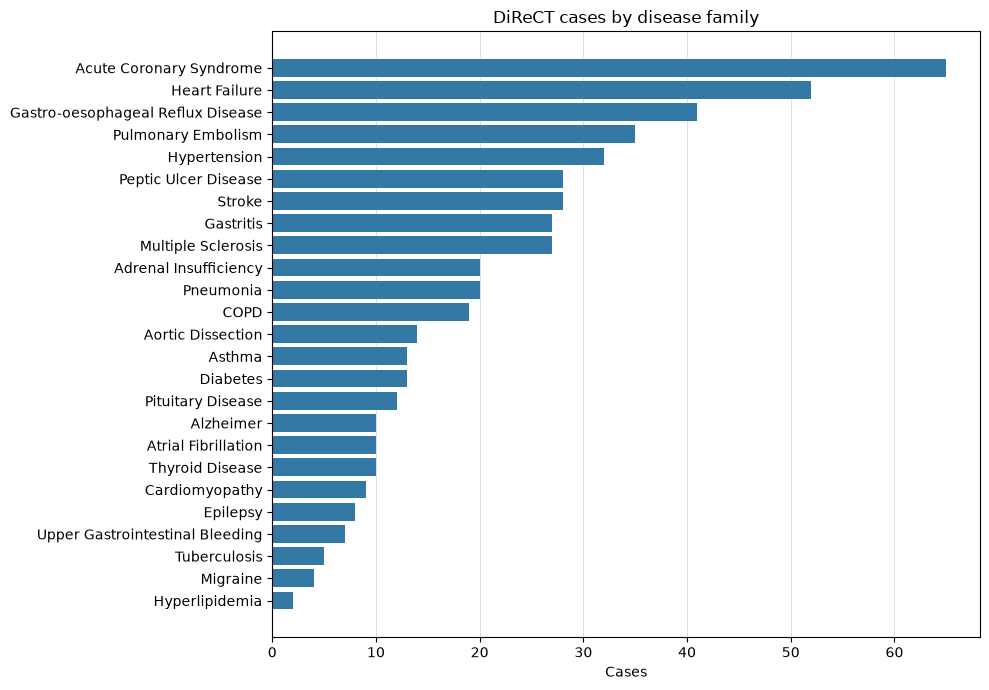

In [5]:
category_counts = Counter(case.disease_category for case in dataset.cases)
category_table = pd.DataFrame(
    sorted(category_counts.items(), key=lambda item: (-item[1], item[0])),
    columns=["disease_category", "case_count"],
)
category_table.to_csv(OUTPUT_DIR / "disease_category_counts.csv", index=False)

figure, axis = plt.subplots(figsize=(10, 7))
ordered = category_table.sort_values("case_count")
axis.barh(ordered["disease_category"], ordered["case_count"], color="#3478A5")
axis.set_xlabel("Cases")
axis.set_ylabel("")
axis.set_title("DiReCT cases by disease family")
axis.grid(axis="x", color="#D8D8D8", linewidth=0.6)
axis.set_axisbelow(True)
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "disease_category_counts.png", dpi=220)
plt.show()

## Guideline graph inventory

In [6]:
case_counts = Counter(case.disease_category for case in dataset.cases)
graphs_by_category = {graph.category: graph for graph in dataset.graphs}
graph_rows = []
for category in sorted(case_counts):
    graph = graphs_by_category.get(category)
    graph_rows.append(
        {
            "disease_category": category,
            "case_count": case_counts[category],
            "graph_available": graph is not None,
            "graph_node_count": len(graph.nodes) if graph else 0,
            "graph_edge_count": len(graph.edges) if graph else 0,
            "diagnosis_count": len(graph.diagnosis_labels) if graph else 0,
            "leaf_diagnosis_count": len(graph.leaf_labels) if graph else 0,
        }
    )

graph_table = pd.DataFrame(graph_rows)
graph_table.to_csv(OUTPUT_DIR / "guideline_graph_inventory.csv", index=False)
graph_table

,disease_category,case_count,graph_available,graph_node_count,graph_edge_count,diagnosis_count,leaf_diagnosis_count
0,Acute Coronary Syndrome,65,True,21,20,6,3
1,Adrenal Insufficiency,20,True,35,34,4,3
2,Alzheimer,10,True,25,24,2,1
3,Aortic Dissection,14,True,9,8,3,2
4,Asthma,13,True,39,38,7,5
5,Atrial Fibrillation,10,True,9,8,3,2
6,COPD,19,True,17,16,6,4
7,Cardiomyopathy,9,True,13,12,5,4
8,Diabetes,13,True,44,43,6,4
9,Epilepsy,8,True,12,11,3,2


## Quality flags

In [7]:
flag_counts = Counter(flag for case in dataset.cases for flag in case.quality_flags)
flag_table = pd.DataFrame(
    sorted(flag_counts.items(), key=lambda item: (-item[1], item[0])),
    columns=["quality_flag", "case_count"],
)
flag_table["case_fraction"] = flag_table["case_count"] / len(dataset.cases)
flag_table.to_csv(OUTPUT_DIR / "quality_flag_counts.csv", index=False)
flag_table

,quality_flag,case_count,case_fraction
0,directory_conclusion_mismatch,115,0.225049
1,missing_guideline_graph,27,0.052838
2,conclusion_not_leaf,14,0.027397
3,empty_input_section,12,0.023483


The quality flags are retained in prediction records. Primary results use all cases; graph-consistent sensitivity results exclude missing graphs, out-of-graph conclusions, and non-leaf conclusions.